In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

# Import wrapper module so joblib can deserialize threshold-aware models.
from thresholding import ThresholdedClassifier


# Load test data
X_test = pd.read_csv(Path(r"data/X_test_selected.csv"))
y_test = pd.read_csv(Path(r"data/y_test.csv")).squeeze("columns")

# Load trained threshold-aware models
logreg_model = joblib.load(Path(r"models/logreg_model.joblib"))
rf_model = joblib.load(Path(r"models/rf_model.joblib"))
xgb_model = joblib.load(Path(r"models/xgb_model.joblib"))
cat_boost = joblib.load(Path(r"models/cat_boost.joblib"))

models = {
    "Logistic Regression": logreg_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "CatBoost": cat_boost,
}

print("Data and threshold-aware models loaded.")
for model_name, model in models.items():
    model_threshold = getattr(model, "threshold", 0.5)
    print(f"{model_name} threshold: {model_threshold:.2f}")


c:\Users\migue\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\migue\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Data and threshold-aware models loaded.
Logistic Regression threshold: 0.30
Random Forest threshold: 0.30
XGBoost threshold: 0.30
CatBoost threshold: 0.30


c:\Users\migue\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\migue\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [21:54:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\data\../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/

## Lift

In [4]:


def cumulative_lift_table(y_true, y_prob):
    """
    Build a cumulative table after sorting cases by predicted probability descending.
    Returns a DataFrame with cumulative gains and lift information.
    """
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_prob = pd.Series(y_prob).reset_index(drop=True)

    df = pd.DataFrame({
        "y_true": y_true,
        "y_prob": y_prob
    }).sort_values("y_prob", ascending=False).reset_index(drop=True)

    df["cum_cases"] = np.arange(1, len(df) + 1)
    df["cum_positives"] = df["y_true"].cumsum()

    total_cases = len(df)
    total_positives = df["y_true"].sum()
    baseline_rate = total_positives / total_cases

    df["population_pct"] = df["cum_cases"] / total_cases
    df["gain"] = df["cum_positives"] / total_positives
    df["precision_at_k"] = df["cum_positives"] / df["cum_cases"]
    df["lift"] = df["precision_at_k"] / baseline_rate

    return df


def plot_cumulative_gains(models, X_test, y_test):
    plt.figure(figsize=(9, 6))

    for model_name, model in models.items():
        y_prob = model.predict_proba(X_test)[:, 1]
        lift_df = cumulative_lift_table(y_test, y_prob)

        plt.plot(
            lift_df["population_pct"],
            lift_df["gain"],
            label=model_name
        )

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("Proportion of population contacted")
    plt.ylabel("Proportion of actual positives captured")
    plt.title("Cumulative Gains Curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_cumulative_lift(models, X_test, y_test):
    plt.figure(figsize=(9, 6))

    for model_name, model in models.items():
        y_prob = model.predict_proba(X_test)[:, 1]
        lift_df = cumulative_lift_table(y_test, y_prob)

        plt.plot(
            lift_df["population_pct"],
            lift_df["lift"],
            label=model_name
        )

    plt.axhline(1.0, linestyle="--", label="Random")
    plt.xlabel("Proportion of population contacted")
    plt.ylabel("Lift")
    plt.title("Cumulative Lift Curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

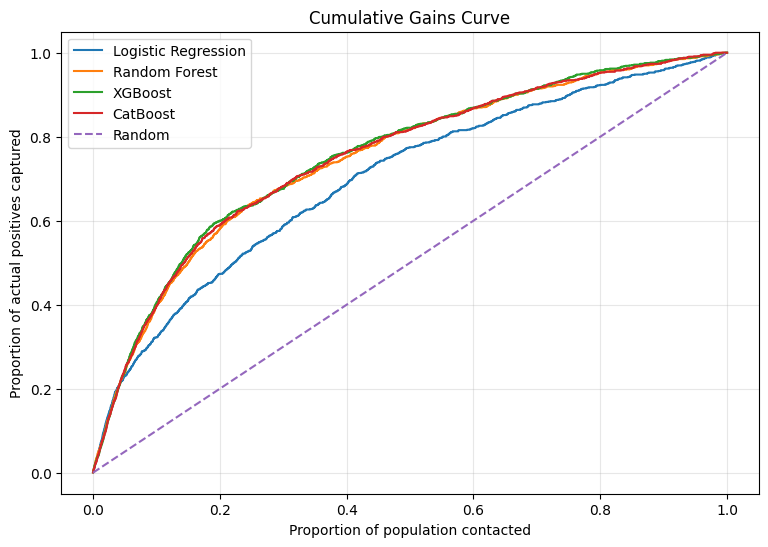

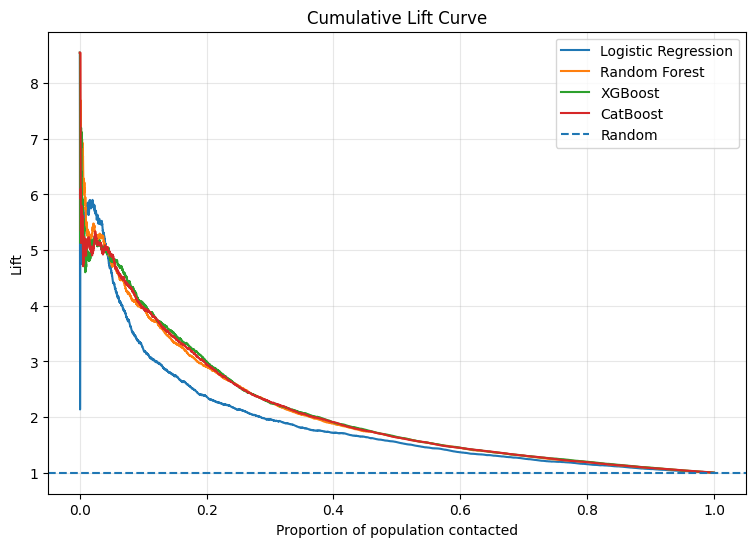

In [5]:
plot_cumulative_gains(models, X_test, y_test)
plot_cumulative_lift(models, X_test, y_test)

## Model specific tables for lift

In [6]:
def summarize_at_selection_rates(y_true, y_prob, selection_rates=(0.1, 0.2, 0.3, 0.4, 0.5)):
    lift_df = cumulative_lift_table(y_true, y_prob)
    rows = []

    for rate in selection_rates:
        idx = max(int(np.ceil(rate * len(lift_df))) - 1, 0)
        row = lift_df.iloc[idx]

        rows.append({
            "selection_rate": rate,
            "gain": row["gain"],
            "lift": row["lift"],
            "precision_at_k": row["precision_at_k"],
            "captured_positives": int(row["cum_positives"]),
            "contacted_clients": int(row["cum_cases"]),
        })

    return pd.DataFrame(rows)

In [7]:
y_prob_cat = models["CatBoost"].predict_proba(X_test)[:, 1]
display(summarize_at_selection_rates(y_test, y_prob_cat))

,selection_rate,gain,lift,precision_at_k,captured_positives,contacted_clients
0,0.1,0.396975,3.966684,0.464088,420,905
1,0.2,0.589792,2.948308,0.344942,624,1809
2,0.3,0.682420,2.274648,0.266126,722,2713
3,0.4,0.763705,1.908841,0.223328,808,3618
4,0.5,0.816635,1.633090,0.191066,864,4522


In [8]:
def get_threshold_for_selection_rate(y_prob, selection_rate):
    """
    Returns the probability threshold that selects approximately
    the top `selection_rate` fraction of observations.
    """
    return np.quantile(y_prob, 1 - selection_rate)

In [9]:
y_prob = models["CatBoost"].predict_proba(X_test)[:, 1]

threshold_10 = get_threshold_for_selection_rate(y_prob, 0.10)
threshold_20 = get_threshold_for_selection_rate(y_prob, 0.20)

print(threshold_10, threshold_20)

0.9769223461100515 0.774777077554545


## Predictions com os 3 modelos


In [10]:
results = []
predictions_dict = {}

for model_name, model in models.items():
    #print current model being evaluated
    print(f"Evaluating {model_name}...")
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    predictions_dict[model_name] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(results_df)


Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating XGBoost...
Evaluating CatBoost...


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.502267,0.172283,0.855388,0.286801,0.787683
3,CatBoost,0.643371,0.214793,0.771267,0.336010,0.784209
1,Random Forest,0.616167,0.203781,0.784499,0.323524,0.780898
0,Logistic Regression,0.392679,0.147536,0.877127,0.252586,0.724964


In [11]:
# Lift vs random baseline (using each model's current threshold)
base_rate = y_test.mean()

lift_rows = []

for model_name, preds in predictions_dict.items():
    y_pred = np.asarray(preds["y_pred"])
    selection_rate = y_pred.mean()

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)

    # Random model baselines
    random_precision = base_rate
    random_recall_same_selection = selection_rate

    lift_rows.append({
        "model": model_name,
        "selection_rate": selection_rate,
        "precision": precision,
        "random_precision": random_precision,
        "precision_lift_vs_random": (precision / random_precision) if random_precision > 0 else np.nan,
        "recall": recall,
        "random_recall_same_selection": random_recall_same_selection,
        "recall_lift_vs_random_same_selection": (
            recall / random_recall_same_selection
        ) if random_recall_same_selection > 0 else np.nan,
    })

lift_df = pd.DataFrame(lift_rows).sort_values("precision_lift_vs_random", ascending=False)
display(lift_df)


,model,selection_rate,precision,random_precision,precision_lift_vs_random,recall,random_recall_same_selection,recall_lift_vs_random_same_selection
3,CatBoost,0.420104,0.214793,0.116997,1.835895,0.771267,0.420104,1.835895
1,Random Forest,0.450404,0.203781,0.116997,1.741769,0.784499,0.450404,1.741769
2,XGBoost,0.580891,0.172283,0.116997,1.472543,0.855388,0.580891,1.472543
0,Logistic Regression,0.695566,0.147536,0.116997,1.261026,0.877127,0.695566,1.261026


In [12]:
for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:
    print(f"\nThreshold = {threshold}")
    
    results = []

    for model_name, model in models.items():
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        results.append({
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "roc_auc": roc_auc_score(y_test, y_prob)
        })

    display(pd.DataFrame(results).sort_values("roc_auc", ascending=False))



Threshold = 0.5


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.650116,0.218750,0.774102,0.341108,0.787683
3,CatBoost,0.746876,0.269043,0.677694,0.385173,0.784209
1,Random Forest,0.753179,0.274057,0.672968,0.389497,0.780898
0,Logistic Regression,0.614398,0.194004,0.727788,0.306346,0.724964



Threshold = 0.6


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.699768,0.241981,0.734405,0.364020,0.787683
3,CatBoost,0.780051,0.296280,0.639887,0.405025,0.784209
1,Random Forest,0.791883,0.309082,0.630435,0.414801,0.780898
0,Logistic Regression,0.690036,0.215891,0.626654,0.321143,0.724964



Threshold = 0.7


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.740352,0.262868,0.675803,0.378507,0.787683
3,CatBoost,0.804158,0.322901,0.614367,0.423315,0.784209
1,Random Forest,0.820745,0.341587,0.573724,0.428219,0.780898
0,Logistic Regression,0.757603,0.250660,0.538752,0.342137,0.724964



Threshold = 0.8


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.779498,0.295276,0.637996,0.403708,0.787683
3,CatBoost,0.826717,0.354155,0.584121,0.440956,0.784209
1,Random Forest,0.846511,0.384292,0.517958,0.441224,0.780898
0,Logistic Regression,0.819087,0.307333,0.435728,0.360438,0.724964



Threshold = 0.9


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.818313,0.342995,0.603970,0.437521,0.787683
3,CatBoost,0.849829,0.393314,0.522684,0.448864,0.784209
1,Random Forest,0.870618,0.443320,0.413989,0.428152,0.780898
0,Logistic Regression,0.862214,0.390187,0.315690,0.349007,0.724964


## Classification reports e confusion matrixes finais



Logistic Regression


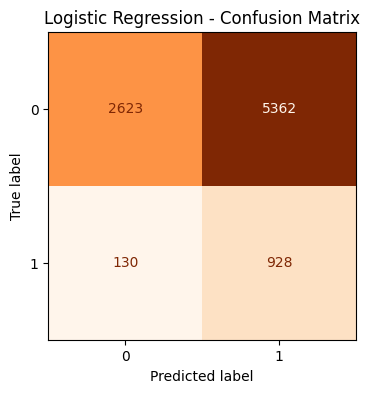


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.33      0.49      7985
           1       0.15      0.88      0.25      1058

    accuracy                           0.39      9043
   macro avg       0.55      0.60      0.37      9043
weighted avg       0.86      0.39      0.46      9043


Random Forest


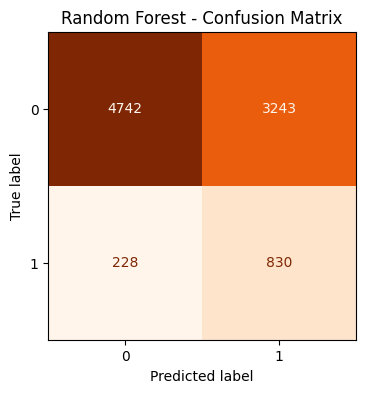


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.59      0.73      7985
           1       0.20      0.78      0.32      1058

    accuracy                           0.62      9043
   macro avg       0.58      0.69      0.53      9043
weighted avg       0.87      0.62      0.68      9043


XGBoost


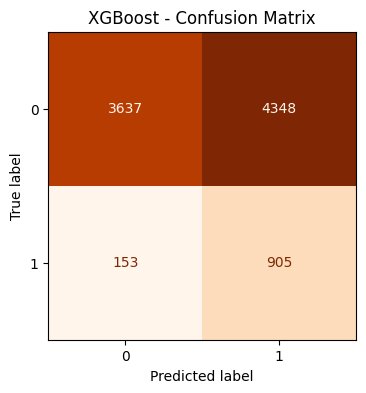


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.46      0.62      7985
           1       0.17      0.86      0.29      1058

    accuracy                           0.50      9043
   macro avg       0.57      0.66      0.45      9043
weighted avg       0.87      0.50      0.58      9043


CatBoost


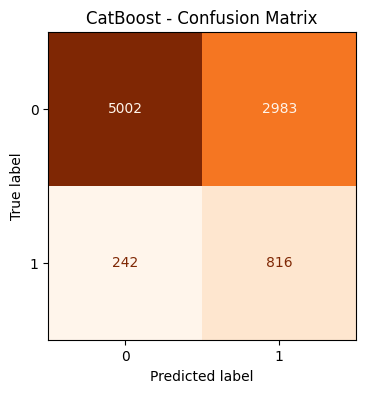


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.63      0.76      7985
           1       0.21      0.77      0.34      1058

    accuracy                           0.64      9043
   macro avg       0.58      0.70      0.55      9043
weighted avg       0.87      0.64      0.71      9043



In [13]:
for model_name, preds in predictions_dict.items():
    print(f"\n{'='*60}")
    print(model_name)
    print(f"{'='*60}")

    # Confusion matrix
    cm = confusion_matrix(y_test, preds["y_pred"])

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot(
        ax=ax,
        cmap="Oranges",
        colorbar=False,
        values_format="d"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, preds["y_pred"]))


## ROC Curve


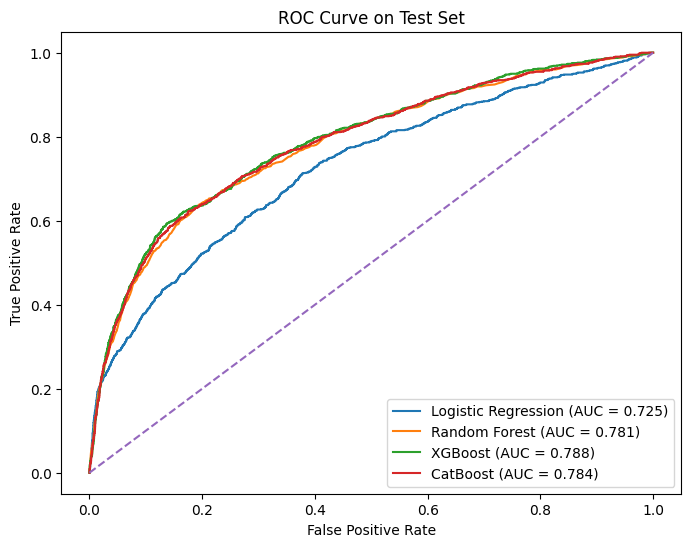

In [14]:
plt.figure(figsize=(8, 6))

for model_name, preds in predictions_dict.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_prob"])
    auc_score = roc_auc_score(y_test, preds["y_prob"])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.show()


## Final feature importances para Random Forest e XGboost


In [15]:
feature_names = X_test.columns

rf_base = getattr(rf_model, "base_model", rf_model)
xgb_base = getattr(xgb_model, "base_model", xgb_model)
cat_base = getattr(cat_boost, "base_model", cat_boost)

# Random Forest feature importance
rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_base.feature_importances_
}).sort_values("importance", ascending=False)

print("Random Forest - Top 15 Feature Importances")
display(rf_importance.head(15))

# XGBoost feature importance
xgb_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_base.feature_importances_
}).sort_values("importance", ascending=False)

print("XGBoost - Top 15 Feature Importances")
display(xgb_importance.head(15))

# CatBoost feature importance
cat_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": cat_base.feature_importances_
}).sort_values("importance", ascending=False)

print("CatBoost - Top 15 Feature Importances")
display(cat_importance.head(15))


Random Forest - Top 15 Feature Importances


,feature,importance
1,balance,0.136048
0,age,0.123400
5,month_sin,0.086779
7,day_sin,0.086033
6,month_cos,0.082067
8,day_cos,0.067812
2,campaign,0.063716
24,housing_yes,0.055892
3,pdays,0.055013
4,previous,0.042664


XGBoost - Top 15 Feature Importances


,feature,importance
28,poutcome_success,0.364156
4,previous,0.130600
24,housing_yes,0.073259
5,month_sin,0.069479
6,month_cos,0.037670
3,pdays,0.027050
19,marital_married,0.026409
22,education_tertiary,0.019725
0,age,0.019597
20,marital_single,0.017510


CatBoost - Top 15 Feature Importances


,feature,importance
5,month_sin,15.990617
6,month_cos,12.069550
0,age,9.816354
7,day_sin,8.703604
24,housing_yes,8.114817
28,poutcome_success,7.925055
3,pdays,7.080254
1,balance,6.720754
8,day_cos,5.956049
2,campaign,4.789992


## Final feature importances para logistic regression


In [16]:
logreg_base = getattr(logreg_model, "base_model", logreg_model)

logreg_importance = pd.DataFrame({
    "feature": X_test.columns,
    "coefficient": logreg_base.coef_[0],
    "abs_coefficient": np.abs(logreg_base.coef_[0])
}).sort_values("abs_coefficient", ascending=False)

print("Logistic Regression - Top 15 Coefficients by Absolute Value")
display(logreg_importance.head(15))


Logistic Regression - Top 15 Coefficients by Absolute Value


,feature,coefficient,abs_coefficient
1,balance,7.707172,7.707172
2,campaign,-5.407678,5.407678
4,previous,4.649850,4.649850
28,poutcome_success,4.579181,4.579181
16,job_student,1.561076,1.561076
13,job_retired,1.522617,1.522617
6,month_cos,1.300408,1.300408
24,housing_yes,-1.253971,1.253971
0,age,-1.180671,1.180671
5,month_sin,0.864982,0.864982


## SHAP analysis


### SHAP para Logistic Regression


In [17]:
! uv pip install shap


error: Broken virtual environment `c:\Users\migue\.venv`: `pyvenv.cfg` is missing


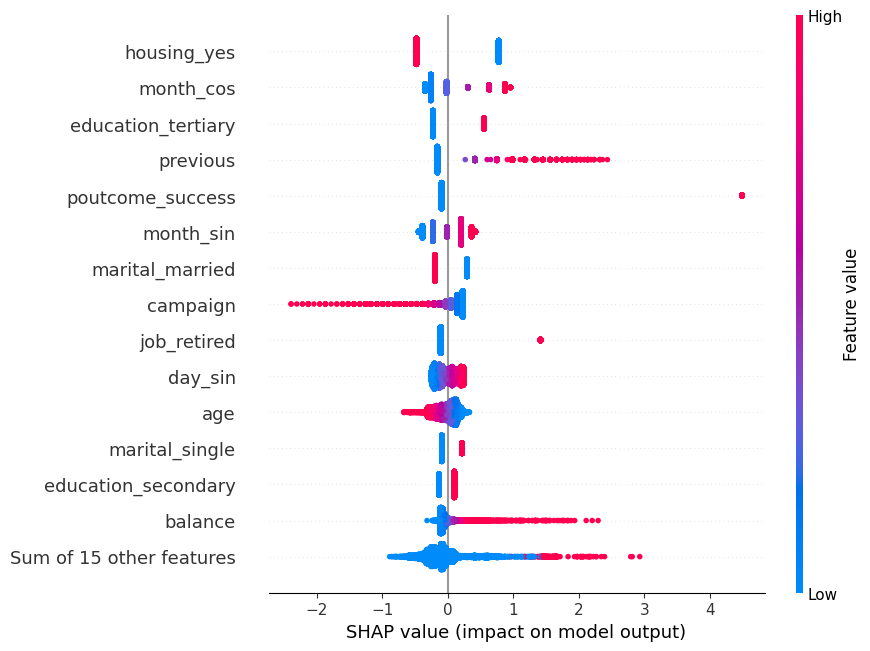

In [18]:
import shap

logreg_base = getattr(logreg_model, "base_model", logreg_model)
explainer_logreg = shap.Explainer(logreg_base, X_test)
shap_values_logreg = explainer_logreg(X_test)

shap.plots.beeswarm(shap_values_logreg, max_display=15)


### SHAP para Random Forest


In [ ]:
rf_base = getattr(rf_model, "base_model", rf_model)
explainer_rf = shap.TreeExplainer(rf_base)
shap_values_rf = explainer_rf.shap_values(X_test)

# For binary classification, use class 1 if shap returns a list
if isinstance(shap_values_rf, list):
    shap.summary_plot(shap_values_rf[1], X_test, max_display=15)
else:
    shap.summary_plot(shap_values_rf, X_test, max_display=15)


### SHAP para XGBoost


In [ ]:
xgb_base = getattr(xgb_model, "base_model", xgb_model)
explainer_xgb = shap.TreeExplainer(xgb_base)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test, max_display=15)


### SHAP para CatBoost


In [ ]:
cat_base = getattr(cat_boost, "base_model", cat_boost)
explainer_cat = shap.TreeExplainer(cat_base)
shap_values_cat = explainer_cat.shap_values(X_test)

shap.summary_plot(shap_values_cat, X_test, max_display=15)


## Guardar final predictions


In [ ]:
predictions_df = X_test.copy()
predictions_df["y_true"] = y_test.values

for model_name, preds in predictions_dict.items():
    safe_name = model_name.lower().replace(" ", "_")
    predictions_df[f"{safe_name}_pred"] = preds["y_pred"]
    predictions_df[f"{safe_name}_prob"] = preds["y_prob"]

predictions_df.to_csv(Path(r"data/test_set_predictions.csv"), index=False)

print("Predictions saved to data/test_set_predictions.csv")
display(predictions_df.head())
